# mnist example

In this notebook we will include all the autodiff code necessary to learn the mnist dataset with an accuracy of $>90%$.

## Outline and Requirements

We will create a node-based structure with all the node types necessary to create a loss function for a feedforwad neural network, with regularisation. In order for regularisation to work properly, topological sorting of nodes will be required, as it introduces a cycle into the computation graph.

Node types required:
- Scalar Variable
- Vector Variable
- Matrix Variable
- Scalar Division
- Scalar Addition
- Vector Addition
- Matrix Addition
- ScalarScalar Multiplication
- VectorScalar Multiplication
- MatrixScalar Multiplication
- MatrixVector Multiplication
- MatrixMatrix Multiplication
- Vector Sum
- Scalar exp
- Vector elementwise exp

In [3]:
import numpy as np

# Node Classes

# Base Expression
# the _b at the end means it supports backward mode
class Expression:
    def __init__(self):
        self.partial = 0
        self.value = 0
        self.children = []
        self.visited = False
        self.nextChild = None
        self.name = None

    def __str__():
        return "EXPRESSION" 
    
    def sort(self, order):
        if self.visited:
            return

        for child in self.children:
            child.sort(order)

        if len(order) > 0:
            self.nextChild = order[0]
        order.insert(0, self)
        self.visited = True

    def eval(self):
        self.partial = 0
        return "CANT EVALUATE BASE EXPRESSION CLASS"

    def derive():
        return "CANT DERIVE OF BASE EXPRESSION CLASS"
    
    def reset_partial(self):
        return

# Base Expression Types
    
class Un_Op(Expression):
    def __init__(self, a):
        Expression.__init__(self)
        self.a = a
        self.children = [a]
    def __str__(self):
        return "[UNARY OP]"
    def reset_partial(self):
        self.partial = np.zeros(self.value.shape)
        self.a.reset_partial()

class Bi_Op(Expression):
    def __init__(self, a, b):
        Expression.__init__(self)
        self.a = a
        self.b = b
        self.children = [a, b]
    def __str__(self):
        return "[BINARY OP]"
    def reset_partial(self):
        self.partial = np.zeros(self.value.shape)
        self.a.reset_partial()
        self.b.reset_partial()
    
# Usable Expression Types

# Constants
class Const(Expression):
    def __init__(self, a):
        Expression.__init__(self)
        self.a = a
        self.name = str(a)
    def __str__(self):
        return str(self.a)
    
    def eval(self):
        self.value = self.a
        return self.a
    def derive(self):
        return 0
    
class VConst(Expression):
    def __init__(self, a):
        Expression.__init__(self)
        self.a = a
        self.name = str(a)
    def __str__(self):
        return str(self.a)
    
    def eval(self):
        self.value = self.a
        return self.a
    def derive(self):
        return np.zeros(self.a.shape)

# Variables  
class Var(Expression):
    def __init__(self, name, value = None):
        '''
        name  : typeof(string)
        value : typeof(float)
        '''
        Expression.__init__(self)
        self.name = name
        self.value = value
        self.partial = 0
    def __str__(self):
        return self.name
    def eval(self):
        return self.value
    def derive(self):
        return 1
    def reset_partial(self):
        self.partial = np.zeros(self.value.shape)
    
# Unary Operations
class Sum(Un_Op):
    def __str__(self):
        return f"Sum({str(self.a)})"
    def eval(self):
        self.value = np.sum(self.a.eval())
        return self.value
    def derive(self):
        dthis_da = np.ones(self.a.value.shape)
        self.a.partial += dthis_da * self.partial
        self.nextChild.derive()
        return
    
class Sin(Un_Op):
    def __str__(self):
        return f"sin({str(self.a)})"
    def eval(self):
        self.value = np.sin(self.a.eval())
        return self.value
    def derive(self):
        dthis_da = np.cos(self.a.value)
        self.a.partial += dthis_da * self.partial # check if this is elementwise for np arrays
        self.nextChild.derive()
        return

class Exp(Un_Op):
    def __str__(self):
        return f"exp({str(self.a)})"
    def eval(self):
        self.value = np.exp(self.a.eval())
        return self.value
    def derive(self):
        dthis_da = np.exp(self.a.value)
        self.a.partial += dthis_da * self.partial # check if this is elementwise for np arrays
        self.nextChild.derive()
        return
    
class Sigmoid(Un_Op):
    def __str__(self):
        return f"Sig({str(self.a)})"
    def eval(self):
        self.value = (1 / (1 + np.exp(- self.a.eval())))
        return self.value
    def derive(self):
        sig_a = 1 / (1 + np.exp(-self.a.value))
        dthis_da = sig_a * (1 - sig_a)
        self.a.partial += dthis_da * self.partial
        self.nextChild.derive()
        return
    
class ReLU(Un_Op):
    def __str__(self):
        return f"ReLU({str(self.a)})"
    def eval(self):
        self.value = np.maximum(0, self.a.eval())
        return self.value
    def derive(self):
        dthis_da = np.array(self.a.value > 0, np.float32)
        self.a.partial += dthis_da * self.partial
        self.nextChild.derive()
        return
    
class L1Norm(Un_Op):
    def __str__(self):
        return f"L1({str(self.a)})"
    def eval(self):
        self.value = np.sum(np.abs(self.a.eval()))
        return self.value
    def derive(self):
        dthis_da = np.sign(self.a.value)
        self.a.partial += dthis_da * self.partial
        self.nextChild.derive()
        return
class L2Norm(Un_Op):
    def __str__(self):
        return f"L2({str(self.a)})"
    def eval(self):
        self.value = np.linalg.norm(self.a.eval(), ord=2)
        return self.value
    def derive(self):
        dthis_da = 2 * self.a.value
        self.a.partial += dthis_da * self.partial
        self.nextChild.derive()
        return

# Binary Operations
class VIdx(Bi_Op):
    def __str__(self):
        return f"{str(self.a)}[{str(self.b)}]"
    def eval(self):
        self.value = self.a.eval()[self.b]
        return self.value
    def derive(self):
        dthis_da = np.zeros(self.a.value.shape)
        dthis_da[self.b] = 1
        self.a.partial += dthis_da * self.partial
        self.nextChild.derive()
        return

class Add(Bi_Op):
    def __str__(self):
        return f"({str(self.a)} + {str(self.b)})"
    def eval(self):
        self.value = self.a.eval() + self.b.eval()
        return self.value   
    def derive(self):
        self.a.partial += self.partial # check if this is elementwise for np arrays
        self.b.partial += self.partial # check if this is elementwise for np arrays
        self.nextChild.derive()

class Sub(Bi_Op):
    def __str__(self):
        return f"({str(self.a)} - {str(self.b)})"
    def eval(self):
        self.value = self.a.eval() - self.b.eval()
        return self.value   
    def derive(self):
        self.a.partial += self.partial # check if this is elementwise for np arrays
        self.b.partial -= self.partial # check if this is elementwise for np arrays
        self.nextChild.derive()    

class Mult(Bi_Op):
    '''
    Multiples:
        vectors * vectors (elementwise),
        scalars * scalars,
        vectors * scalars, or
        scalars * vectors
    '''
    def __str__(self):
        return f"({str(self.a)} * {str(self.b)})"
    def eval(self):
        self.value = self.a.eval() * self.b.eval()
        return self.value   
    def derive(self):
        dthis_da = self.b.value 
        dthis_db = self.a.value
        self.a.partial += dthis_da * self.partial
        self.b.partial += dthis_db * self.partial
        self.nextChild.derive()        

class PowInt(Un_Op):
    def __init__(self, a, p):
        Un_Op.__init__(self, a)
        self.p = p
    def __str__(self):
        return f"({str(self.a)} ^ {str(self.p)})"
    def reset_partial(self):
        self.partial = np.zeros(self.value.shape)
        self.a.reset_partial()
    def eval(self):
        self.value = np.power(self.a.eval(),  self.p)
        return self.value   
    def derive(self):
        dthis_da = self.p * np.power(self.a.value, (self.p - 1))
        self.a.partial += dthis_da * self.partial
        self.nextChild.derive()

class MVMult(Bi_Op):
    def __str__(self):
        return f"({str(self.a)} @ {str(self.b)})"  
    def eval(self):
        self.value = np.matmul(self.a.eval(), self.b.eval())
        return self.value
    def derive(self):
        dthis_da = np.transpose(np.array([self.b.value]))
        dthis_db = np.transpose(self.a.value)
        self.a.partial += np.array([self.partial]).T @ dthis_da.T # no sure why i need to transpose the partial, will need to work through the linear algebra again on paper
        self.b.partial += dthis_db @ self.partial
        self.nextChild.derive()

## Constructing Neural Network and Loss function

In [4]:
import matplotlib.pyplot as plt

# Hardcoded feedforward NN example
# our nn architecture:
#
#
# R^l0      R^l1            R^l2            R^l3
# x -> activation_1 -> activation_2 -> outputs
# f(x) = s(W_23 @ s(W_12 @ s(W_01 @ inputs + b_1) + b_2) + b_3)

layerSizes = [2, 2, 1]

x = Var("x", np.ones([layerSizes[0]]))

W_01 = Var("W_01", np.random.normal(0, 1/layerSizes[0], [layerSizes[1], layerSizes[0]]))
W_12 = Var("W_12", np.random.normal(0, 1/layerSizes[1], [layerSizes[2], layerSizes[1]]))
W = [W_01, W_12]

b_1 = Var("b_1", np.zeros([layerSizes[1]]))
b_2 = Var("b_2", np.zeros([layerSizes[2]]))
b = [b_1, b_2]

variables = W + b # list of all variable objects, needed for resetting their partials for repeated evaluation

y_desired = Var("y", np.array([0]))
output = Sigmoid(ReLU(Add(MVMult(W_12, ReLU(Add(MVMult(W_01, x), b_1))), b_2)))
cost = Add(Sum(PowInt(Sub(y_desired, output), 2)), Mult(Add(L2Norm(W_01), L2Norm(W_12)), Const(0.01)))

cost.name = "cost"

print(output)
print(cost)

topo_order = []
cost.sort(topo_order)

print(cost.eval())
cost.partial = 1

# reset partial derivatives of each node
cost.reset_partial()

cost.partial = np.ones(cost.value.shape)
cost.derive()

print(b_1.partial)

Sig(ReLU(((W_12 @ ReLU(((W_01 @ x) + b_1))) + b_2)))
(Sum(((Sig(ReLU(((W_12 @ ReLU(((W_01 @ x) + b_1))) + b_2))) - y) ^ 2)) + ((L2(W_01) + L2(W_12)) * 0.01))
0.2610071299956058
[0. 0.]


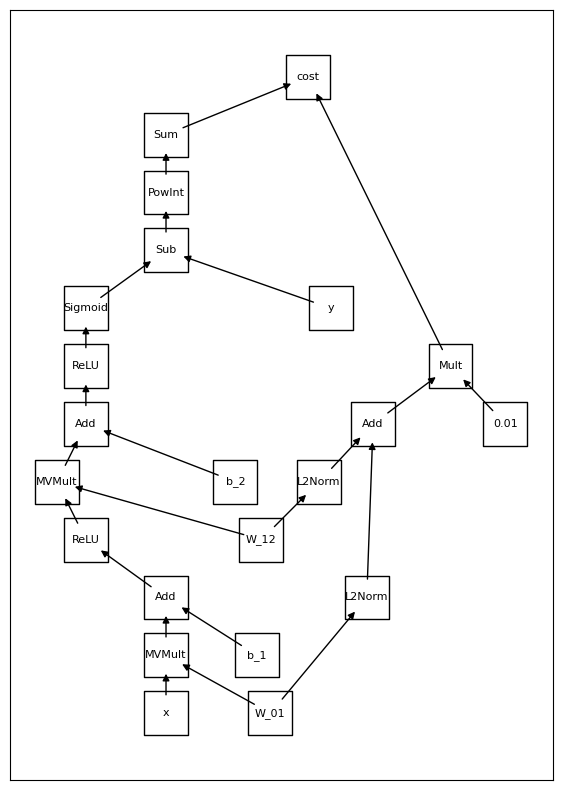

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import pydot
from networkx.drawing.nx_pydot import graphviz_layout

G = nx.DiGraph()

labels = {}

def AddNodeToGraph(graph, node):
    graph.add_node(str(node))
    if node.name == None:
        labels[str(node)] = type(node).__name__
    else:
        labels[str(node)] = node.name

    if len(node.children) > 0:
      for child in node.children:
        graph.add_edge(str(node), str(child))
        AddNodeToGraph(graph, child)
    return

AddNodeToGraph(G, cost)

pos = graphviz_layout(G, prog="dot")
for k,v in pos.items():
    pos[k]=(v[0],v[1])

plt.figure(figsize=(7,10))

nx.draw_networkx_nodes(G,pos = pos, node_shape = 's', node_size = 1000, 
                       node_color = 'none', edgecolors='k')
nx.draw_networkx_edges(G,pos = pos, 
                       node_shape = 's', width = 1,  node_size = 350, arrowstyle="<|-")
nx.draw_networkx_labels(G, pos = pos, labels = labels, font_size = 8)

plt.show()

[0.55771572]
[array([0.51777296]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.52141298]), array([0.53084395]), array([0.53189027]), array([0.5]), array([0.50642868]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.50226342]), array([0.54697917]), array([0.53198023]), array([0.52924977]), array([0.5]), array([0.5]), array([0.53506352]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.50021251]), array([0.52067933]), array([0.5]), array([0.52740292]), array([0.52926283]), array([0.5]), array([0.55040989]), array([0.5]), array([0.51781536]), array([0.51977488]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.53643165]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.5]), array([0.51986384]), array([0.5]),

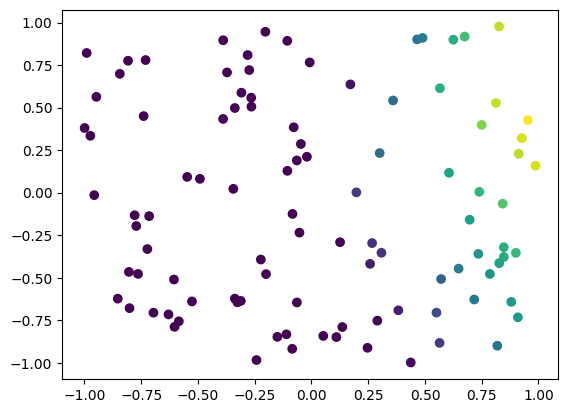

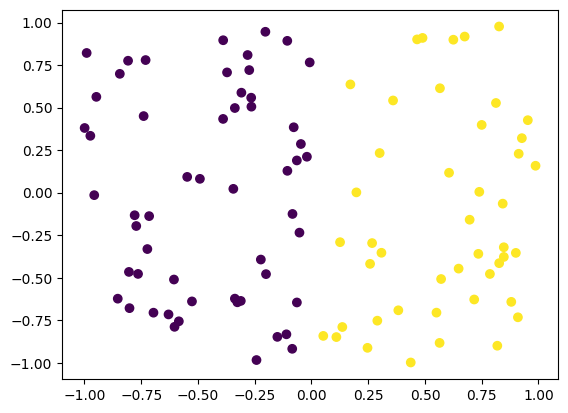

KeyboardInterrupt: 

In [7]:


print(output.eval())

#generate synthetic data
n_train = 100
x_train = [np.random.uniform(-1,1,x.value.shape) for n in range(n_train)]
y_train = [np.array([(np.sign(x_train[n][0]) + 1) / 2]) for n in range(n_train)]

def showResult():
    outputs = []

    for x_t in x_train:
        x.value = x_t
        outputs.append(output.eval())

    print(outputs)

    plt.scatter([x_t[0] for x_t in x_train], [x_t[1] for x_t in x_train], c=outputs)
    plt.show()
    plt.scatter([x_t[0] for x_t in x_train], [x_t[1] for x_t in x_train], c=y_train)
    plt.show()

showResult()

costs = []

def trainBatchSGD(x_batch, y_batch, rate):
    batchSize = len(x_batch)
    totalGrads = [np.zeros(v.value.shape) for v in variables]
    avgCost = 0
    for i in range(batchSize):
        # set x, y values for cost evaluation and derivation
        x.value = x_batch[i]
        y_desired.value = y_batch[i]

        avgCost += cost.eval()/batchSize
        #print(y_desired.value, output.value, cost.value)

        # reset partial derivatives of each node
        cost.reset_partial()

        cost.partial = np.ones(cost.value.shape)
        cost.derive()

        for j in range(len(totalGrads)):
            #print(variables[j].name, variables[j].partial)
            totalGrads[j] += variables[j].partial #/ np.linalg.norm(variables[j].partial)

    # update parameters based on average grad * learning rate
    for j in range(len(totalGrads)):
        variables[j].value -= totalGrads[j] * rate / batchSize
    costs.append(avgCost) 

for epoch in range(100):
    trainBatchSGD(x_train, y_train, 0.1)

plt.plot(costs)
plt.show()
showResult()